In [1]:
import torch 
from torch import nn 
import os 
from pathlib import Path

In [2]:
data_path = Path('Data/')

train_images_path = data_path / 'seg_train'
test_images_path = data_path / 'seg_test'

In [3]:
def check_data(dir_path) : 
    for dirpath, dirnames, filenames in os.walk(dir_path) :
        print(f"# of directories: {len(dirnames)} and {len(filenames)} images in '{dirpath}'.")

check_data(data_path)

# of directories: 3 and 0 images in 'Data'.
# of directories: 0 and 7301 images in 'Data\seg_pred'.
# of directories: 6 and 0 images in 'Data\seg_test'.
# of directories: 0 and 437 images in 'Data\seg_test\buildings'.
# of directories: 0 and 474 images in 'Data\seg_test\forest'.
# of directories: 0 and 553 images in 'Data\seg_test\glacier'.
# of directories: 0 and 525 images in 'Data\seg_test\mountain'.
# of directories: 0 and 510 images in 'Data\seg_test\sea'.
# of directories: 0 and 501 images in 'Data\seg_test\street'.
# of directories: 6 and 0 images in 'Data\seg_train'.
# of directories: 0 and 2191 images in 'Data\seg_train\buildings'.
# of directories: 0 and 2271 images in 'Data\seg_train\forest'.
# of directories: 0 and 2404 images in 'Data\seg_train\glacier'.
# of directories: 0 and 2512 images in 'Data\seg_train\mountain'.
# of directories: 0 and 2274 images in 'Data\seg_train\sea'.
# of directories: 0 and 2382 images in 'Data\seg_train\street'.


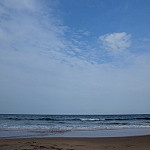

In [4]:
import random
from PIL import Image

image_path_list = list(train_images_path.glob('*/*.jpg'))

random_image = random.choice(image_path_list)

image_class = random_image.parent.stem

img = Image.open(random_image)

img



In [5]:
import torchvision 
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize(size = (150 , 150)),
    transforms.RandomHorizontalFlip(p = 0.3),
    transforms.ColorJitter(brightness = 0.1 , contrast = 0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
test_transforms = transforms.Compose([
    transforms.Resize(size = (150 , 150)),
    transforms.ColorJitter(brightness = 0.1 , contrast = 0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [6]:
from torchvision import datasets

train_data = datasets.ImageFolder(
    root = train_images_path , 
    transform = train_transforms , 
    target_transform = None 
)
test_data = datasets.ImageFolder(
    root = test_images_path , 
    transform = test_transforms ,
    target_transform = None
)

In [7]:
train_data

Dataset ImageFolder
    Number of datapoints: 14034
    Root location: Data\seg_train
    StandardTransform
Transform: Compose(
               Resize(size=(150, 150), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.3)
               ColorJitter(brightness=(0.9, 1.1), contrast=(0.8, 1.2), saturation=None, hue=None)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [8]:
test_data

Dataset ImageFolder
    Number of datapoints: 3000
    Root location: Data\seg_test
    StandardTransform
Transform: Compose(
               Resize(size=(150, 150), interpolation=bilinear, max_size=None, antialias=True)
               ColorJitter(brightness=(0.9, 1.1), contrast=(0.8, 1.2), saturation=None, hue=None)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [10]:
class_names = train_data.classes
class_names

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

In [11]:
len(train_data), len(test_data)

(14034, 3000)

In [12]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_datalaoder = DataLoader(
    dataset = train_data , 
    batch_size = BATCH_SIZE ,
    shuffle = True
)
test_dataloader = DataLoader(
    dataset = test_data , 
    batch_size = BATCH_SIZE ,
    shuffle = True 
)

In [13]:
class Classifier(nn.Module) : 
    def __init__(self , input_shape , hidden_units , output_shape ) :
        super().__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(
                in_channels = input_shape , 
                out_channels = hidden_units ,
                kernel_size = 3 ,
                stride = 2 ,
                padding = 1 
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels = hidden_units , 
                out_channels = hidden_units ,
                kernel_size = 3 , 
                stride = 1 ,
                padding = 1
            ),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size = 2 , 
                stride = 2 
            )
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(
                in_channels = hidden_units , 
                out_channels = hidden_units ,
                kernel_size = 3 , 
                stride = 1 , 
                padding = 1
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels = hidden_units , 
                out_channels = hidden_units ,
                kernel_size = 3 ,
                stride = 1 ,
                padding = 1
            ),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size = 2 , 
                stride = 2
            )
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = hidden_units * 18 * 18 , out_features = output_shape)
        )

    def forward(self , x ) : 
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.classifier(x)
        return x 

In [14]:
model_0 = Classifier(
    input_shape = 3 ,
    hidden_units = 32 , 
    output_shape = len(class_names)
)

from torchinfo import summary
summary(model_0 , input_size = [1 , 3 , 150 , 150])

Layer (type:depth-idx)                   Output Shape              Param #
Classifier                               [1, 6]                    --
├─Sequential: 1-1                        [1, 32, 37, 37]           --
│    └─Conv2d: 2-1                       [1, 32, 75, 75]           896
│    └─ReLU: 2-2                         [1, 32, 75, 75]           --
│    └─Conv2d: 2-3                       [1, 32, 75, 75]           9,248
│    └─ReLU: 2-4                         [1, 32, 75, 75]           --
│    └─MaxPool2d: 2-5                    [1, 32, 37, 37]           --
├─Sequential: 1-2                        [1, 32, 18, 18]           --
│    └─Conv2d: 2-6                       [1, 32, 37, 37]           9,248
│    └─ReLU: 2-7                         [1, 32, 37, 37]           --
│    └─Conv2d: 2-8                       [1, 32, 37, 37]           9,248
│    └─ReLU: 2-9                         [1, 32, 37, 37]           --
│    └─MaxPool2d: 2-10                   [1, 32, 18, 18]           --
├─Seq

In [15]:
from torchmetrics.classification import MulticlassAccuracy

accuracy = MulticlassAccuracy(num_classes = len(class_names)).to(device)

In [16]:
def train_step(
    model : nn.Module ,
    dataset : torch.utils.data.DataLoader ,
    loss_fn : nn.Module , 
    optimizer : torch.optim.Optimizer,
    device
    ) : 
    model.train()

    train_acc = 0
    train_loss = 0
    for epoch , (X , y ) in enumerate(dataset) : 
        X , y = X.to(device) , y.to(device)
        
        y_pred_logits = model(X)

        loss = loss_fn(y_pred_logits , y )
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        y_pred_labels = torch.softmax(input = y_pred_logits , dim = 1 ).argmax(dim = 1 )

        train_acc += accuracy(y_pred_labels , y)

    train_loss /= len(dataset)
    train_acc /= len(dataset)

    return train_loss , train_acc

In [17]:
def test_step(
        model : nn.Module , 
        dataset : torch.utils.data.DataLoader,
        loss_fn : nn.Module ,
        device
):

    model.eval()

    test_loss = 0
    test_acc = 0 
    
    with torch.inference_mode():
        for X , y in dataset :
            X , y = X.to(device) , y.to(device)
            y_pred_logits = model(X)

            loss = loss_fn(y_pred_logits , y )

            test_loss += loss.item()

            test_pred_labels = torch.softmax(input = y_pred_logits , dim = 1 ).argmax(dim = 1)

            test_acc += accuracy(test_pred_labels , y)

        test_loss /= len(dataset)
        test_acc /= len(dataset)

        return test_loss , test_acc

In [18]:
from torch.utils.tensorboard.writer import SummaryWriter

In [19]:


def train_model(
        model : nn.Module , 
        train_dataloader : torch.utils.data.DataLoader ,
        test_dataloader : torch.utils.data.DataLoader ,
        loss_fn : nn.Module ,
        optimizer : torch.optim.Optimizer , 
        device ,
        expreiment_name ,
        epochs : int = 10
                ) :
        
        writer = SummaryWriter(log_dir = f'runs/{expreiment_name}')
        for epoch in range(epochs):
                train_loss , train_acc = train_step(
                model = model , 
                dataset = train_dataloader , 
                loss_fn = loss_fn , 
                optimizer = optimizer , 
                device = device
        )

                test_loss , test_acc = test_step(
                model = model , 
                dataset = test_dataloader ,
                loss_fn = loss_fn , 
                device = device
        )
                print(
                f"Epoch: {epoch+1} | "
                f"train_loss: {train_loss:.4f} | "
                f"train_acc: {train_acc:.4f} | "
                f"test_loss: {test_loss:.4f} | "
                f"test_acc: {test_acc:.4f}"
        )
                
                writer.add_scalars(
                        main_tag = 'Loss' , 
                        tag_scalar_dict = {
                                'Train Loss' : train_loss ,
                                'Test Loss' : test_loss
                        },
                        global_step = epoch
                )
                writer.add_scalars(
                        main_tag = 'Accuracy' , 
                        tag_scalar_dict = {
                                'Train Accuracy' : train_acc , 
                                'Test Accuracy' : test_acc
                        },
                        global_step = epoch
                )
        writer.close()

In [20]:
EPOCHS = 15 

model = Classifier(
    input_shape = 3 ,
    hidden_units = 32 , 
    output_shape = len(class_names)
)

model = model.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model.parameters() , lr = 0.001)

train_model(
    model = model , 
    train_dataloader = train_datalaoder , 
    test_dataloader = test_dataloader , 
    loss_fn = loss_fn , 
    optimizer = optimizer ,
    device = device , 
    expreiment_name = 'Model0_32_units'
)

Epoch: 1 | train_loss: 0.9182 | train_acc: 0.6446 | test_loss: 0.6567 | test_acc: 0.7720
Epoch: 2 | train_loss: 0.6061 | train_acc: 0.7820 | test_loss: 0.5571 | test_acc: 0.7999
Epoch: 3 | train_loss: 0.5076 | train_acc: 0.8172 | test_loss: 0.6006 | test_acc: 0.7822
Epoch: 4 | train_loss: 0.4478 | train_acc: 0.8411 | test_loss: 0.4875 | test_acc: 0.8132
Epoch: 5 | train_loss: 0.4086 | train_acc: 0.8504 | test_loss: 0.5104 | test_acc: 0.8163
Epoch: 6 | train_loss: 0.3571 | train_acc: 0.8749 | test_loss: 0.5028 | test_acc: 0.8299
Epoch: 7 | train_loss: 0.3207 | train_acc: 0.8851 | test_loss: 0.4924 | test_acc: 0.8301
Epoch: 8 | train_loss: 0.2913 | train_acc: 0.8984 | test_loss: 0.5213 | test_acc: 0.8308
Epoch: 9 | train_loss: 0.2539 | train_acc: 0.9104 | test_loss: 0.5125 | test_acc: 0.8379
Epoch: 10 | train_loss: 0.2352 | train_acc: 0.9173 | test_loss: 0.5562 | test_acc: 0.8376


In [28]:
%reload_ext tensorboard
%tensorboard --logdir runs --port 8080

Reusing TensorBoard on port 8080 (pid 15636), started 0:00:04 ago. (Use '!kill 15636' to kill it.)

In [32]:
import matplotlib.pyplot as plt
import random
import torch

def show_random_predictions(model, dataset, class_names, n=9):
    # 1. Modelin hangi cihazda (CPU veya CUDA) olduğunu otomatik olarak tespit ediyoruz
    device = next(model.parameters()).device
    
    model.eval()
    
    # 9 görsel için 4x4 biraz küçük kalabilir, daha net görmek için 10x10 idealdir
    plt.figure(figsize=(10, 10))

    # random 9 index seç
    indices = random.sample(range(len(dataset)), n)

    with torch.inference_mode():
        for i, idx in enumerate(indices):
            img, true_label = dataset[idx]

            # 2. KRİTİK DÜZELTME: Görüntüyü boyutlandır ve modelin bulunduğu cihaza (GPU/CPU) taşı
            img_input = img.unsqueeze(0).to(device)  
            
            logits = model(img_input)
            pred_label = logits.argmax(dim=1).item()

            # 3. Görseli Matplotlib ile çizmek için CPU'ya geri almalı ve permute etmeliyiz
            # Eğer veri GPU'daysa matplotlib doğrudan çizemez, bu yüzden .cpu() ekliyoruz
            img_show = img.cpu().permute(1, 2, 0)

            # Doğru mu yanlış mı?
            correct = (pred_label == true_label)
            color = "green" if correct else "red"

            # Subplot
            plt.subplot(3, 3, i + 1)
            plt.imshow(img_show)
            plt.axis("off")

            plt.title(
                f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}",
                color=color,
                fontsize=10
            )

    plt.tight_layout()
    plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4831376].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.2216995].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.5528543].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9295317..2.0125492].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.343704].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8952821..2.4482791].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9466565..2.29

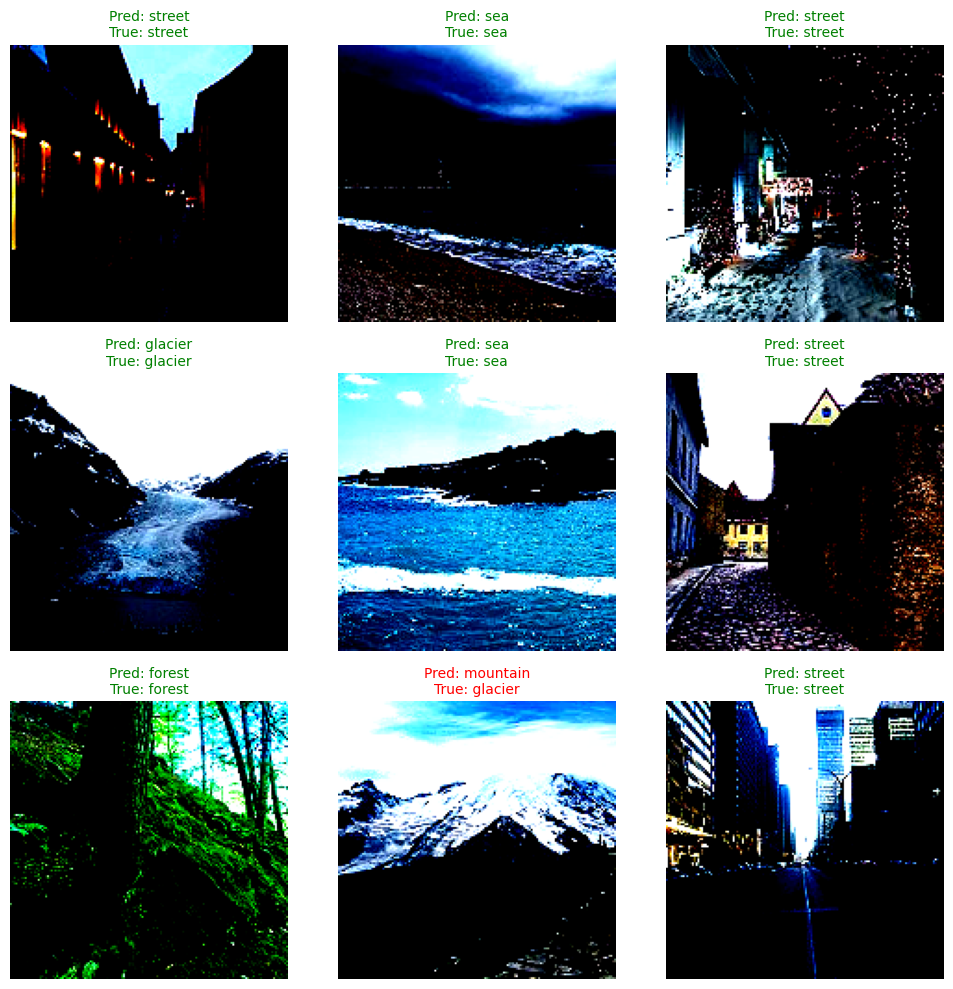

In [33]:
show_random_predictions(model, test_data , class_names)